# Week 4 - Exercise 3.1: Pairwise Crime Scatterplots

This notebook creates 36 scatterplots comparing all pairs of your 9 Personal Focus Crimes.

Each scatterplot shows:
- X-axis: Hourly counts for Crime Type 1
- Y-axis: Hourly counts for Crime Type 2
- Each point represents one hour of the week (168 total points)

**Goal:** Identify which crime types have similar temporal patterns (correlated) and which are different (uncorrelated).

## Step 1: Load Data and Libraries

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [2]:
# Load the merged crime data
df = pd.read_csv('../files/merged_crime_data_2003_2025.csv')
df['Incident_Date'] = pd.to_datetime(df['Incident_Date'])

print(f"✓ Data loaded successfully")
print(f"  Total records: {len(df):,}")
print(f"  Date range: {df['Incident_Date'].min().date()} to {df['Incident_Date'].max().date()}")
print(f"\nAvailable crime categories:")
print(df['Unified_Category'].value_counts())

✓ Data loaded successfully
  Total records: 1,317,318
  Date range: 2003-01-01 to 2025-12-31

Available crime categories:
Unified_Category
Larceny/Theft         695660
Assault               163109
Vehicle Theft         144241
Burglary              119319
Robbery                58445
Fraud                  54235
Missing Person         52608
Disorderly Conduct     17555
Arson                   5443
Embezzlement            3512
Suicide                 1599
Liquor Laws             1592
Name: count, dtype: int64


## Step 2: Select Your 9 Personal Focus Crimes

In [3]:
# YOUR 9 PERSONAL FOCUS CRIMES (from Week 2)
personal_focus_crimes = [
    'Arson',
    'Assault',
    'Burglary',
    'Disorderly Conduct',
    'Embezzlement',
    'Fraud',
    'Larceny/Theft',
    'Liquor Laws',
    'Missing Person'
]

# Filter to your Personal Focus Crimes
df_focus = df[df['Unified_Category'].isin(personal_focus_crimes)].copy()

print(f"✓ Selected {len(personal_focus_crimes)} Personal Focus Crimes")
print(f"✓ Total records for analysis: {len(df_focus):,}")
print(f"\nRecords per crime type:")
for crime in personal_focus_crimes:
    count = len(df_focus[df_focus['Unified_Category'] == crime])
    print(f"  {crime:25s}: {count:,}")

✓ Selected 9 Personal Focus Crimes
✓ Total records for analysis: 1,113,033

Records per crime type:
  Arson                    : 5,443
  Assault                  : 163,109
  Burglary                 : 119,319
  Disorderly Conduct       : 17,555
  Embezzlement             : 3,512
  Fraud                    : 54,235
  Larceny/Theft            : 695,660
  Liquor Laws              : 1,592
  Missing Person           : 52,608


## Step 3: Create Hour-of-Week Vectors

We'll create a vector for each crime type showing how many crimes occurred in each hour of the week:
- Hour 0 = Sunday midnight to 1am
- Hour 167 = Saturday 11pm to midnight

In [4]:
# Create hour-of-week feature (0-167)
# Sunday midnight = 0, Saturday 11pm = 167
df_focus['DayOfWeek'] = df_focus['Incident_Date'].dt.dayofweek  # Monday=0, Sunday=6
df_focus['DayOfWeek_Sunday0'] = (df_focus['DayOfWeek'] + 1) % 7  # Convert to Sunday=0
df_focus['HourOfWeek'] = df_focus['DayOfWeek_Sunday0'] * 24 + df_focus['Hour']

# Create hourly counts for each crime type
hourly_counts = {}

for crime in personal_focus_crimes:
    crime_data = df_focus[df_focus['Unified_Category'] == crime]
    # Count crimes per hour of week
    counts = crime_data.groupby('HourOfWeek').size()
    # Ensure all 168 hours are represented (fill missing with 0)
    full_counts = pd.Series(0, index=range(168))
    full_counts.update(counts)
    hourly_counts[crime] = full_counts.values

print("✓ Created hourly count vectors for each crime type")
print(f"  Each vector has {len(hourly_counts[personal_focus_crimes[0]])} values (168 hours)")
print(f"\nExample - {personal_focus_crimes[0]} hourly counts (first 24 hours - Sunday):")
print(hourly_counts[personal_focus_crimes[0]][:24])

✓ Created hourly count vectors for each crime type
  Each vector has 168 values (168 hours)

Example - Arson hourly counts (first 24 hours - Sunday):
[61 42 56 49 39 36 36 32 25 24 13 15 21 22 22 28 26 28 25 37 34 41 52 46]


## Step 4: Generate All Pairwise Combinations

With 9 crimes, we get C(9,2) = 36 unique pairs

In [5]:
# Generate all pairwise combinations
crime_pairs = list(combinations(personal_focus_crimes, 2))

print(f"✓ Generated {len(crime_pairs)} pairwise combinations")
print(f"  Formula: C(9,2) = 9!/(2!(9-2)!) = {len(crime_pairs)}")
print(f"\nAll {len(crime_pairs)} pairs:")
for i, (c1, c2) in enumerate(crime_pairs, 1):
    print(f"  {i:2d}. {c1:25s} vs {c2}")

✓ Generated 36 pairwise combinations
  Formula: C(9,2) = 9!/(2!(9-2)!) = 36

All 36 pairs:
   1. Arson                     vs Assault
   2. Arson                     vs Burglary
   3. Arson                     vs Disorderly Conduct
   4. Arson                     vs Embezzlement
   5. Arson                     vs Fraud
   6. Arson                     vs Larceny/Theft
   7. Arson                     vs Liquor Laws
   8. Arson                     vs Missing Person
   9. Assault                   vs Burglary
  10. Assault                   vs Disorderly Conduct
  11. Assault                   vs Embezzlement
  12. Assault                   vs Fraud
  13. Assault                   vs Larceny/Theft
  14. Assault                   vs Liquor Laws
  15. Assault                   vs Missing Person
  16. Burglary                  vs Disorderly Conduct
  17. Burglary                  vs Embezzlement
  18. Burglary                  vs Fraud
  19. Burglary                  vs Larceny/Theft
  20. Bu

## Step 5: Create 6x6 Subplot Matrix

This is the main visualization - 36 scatterplots in a 6x6 grid


✓ Created 6x6 matrix of 36 scatterplots
✓ Saved as 'crime_pairwise_scatterplots.png'


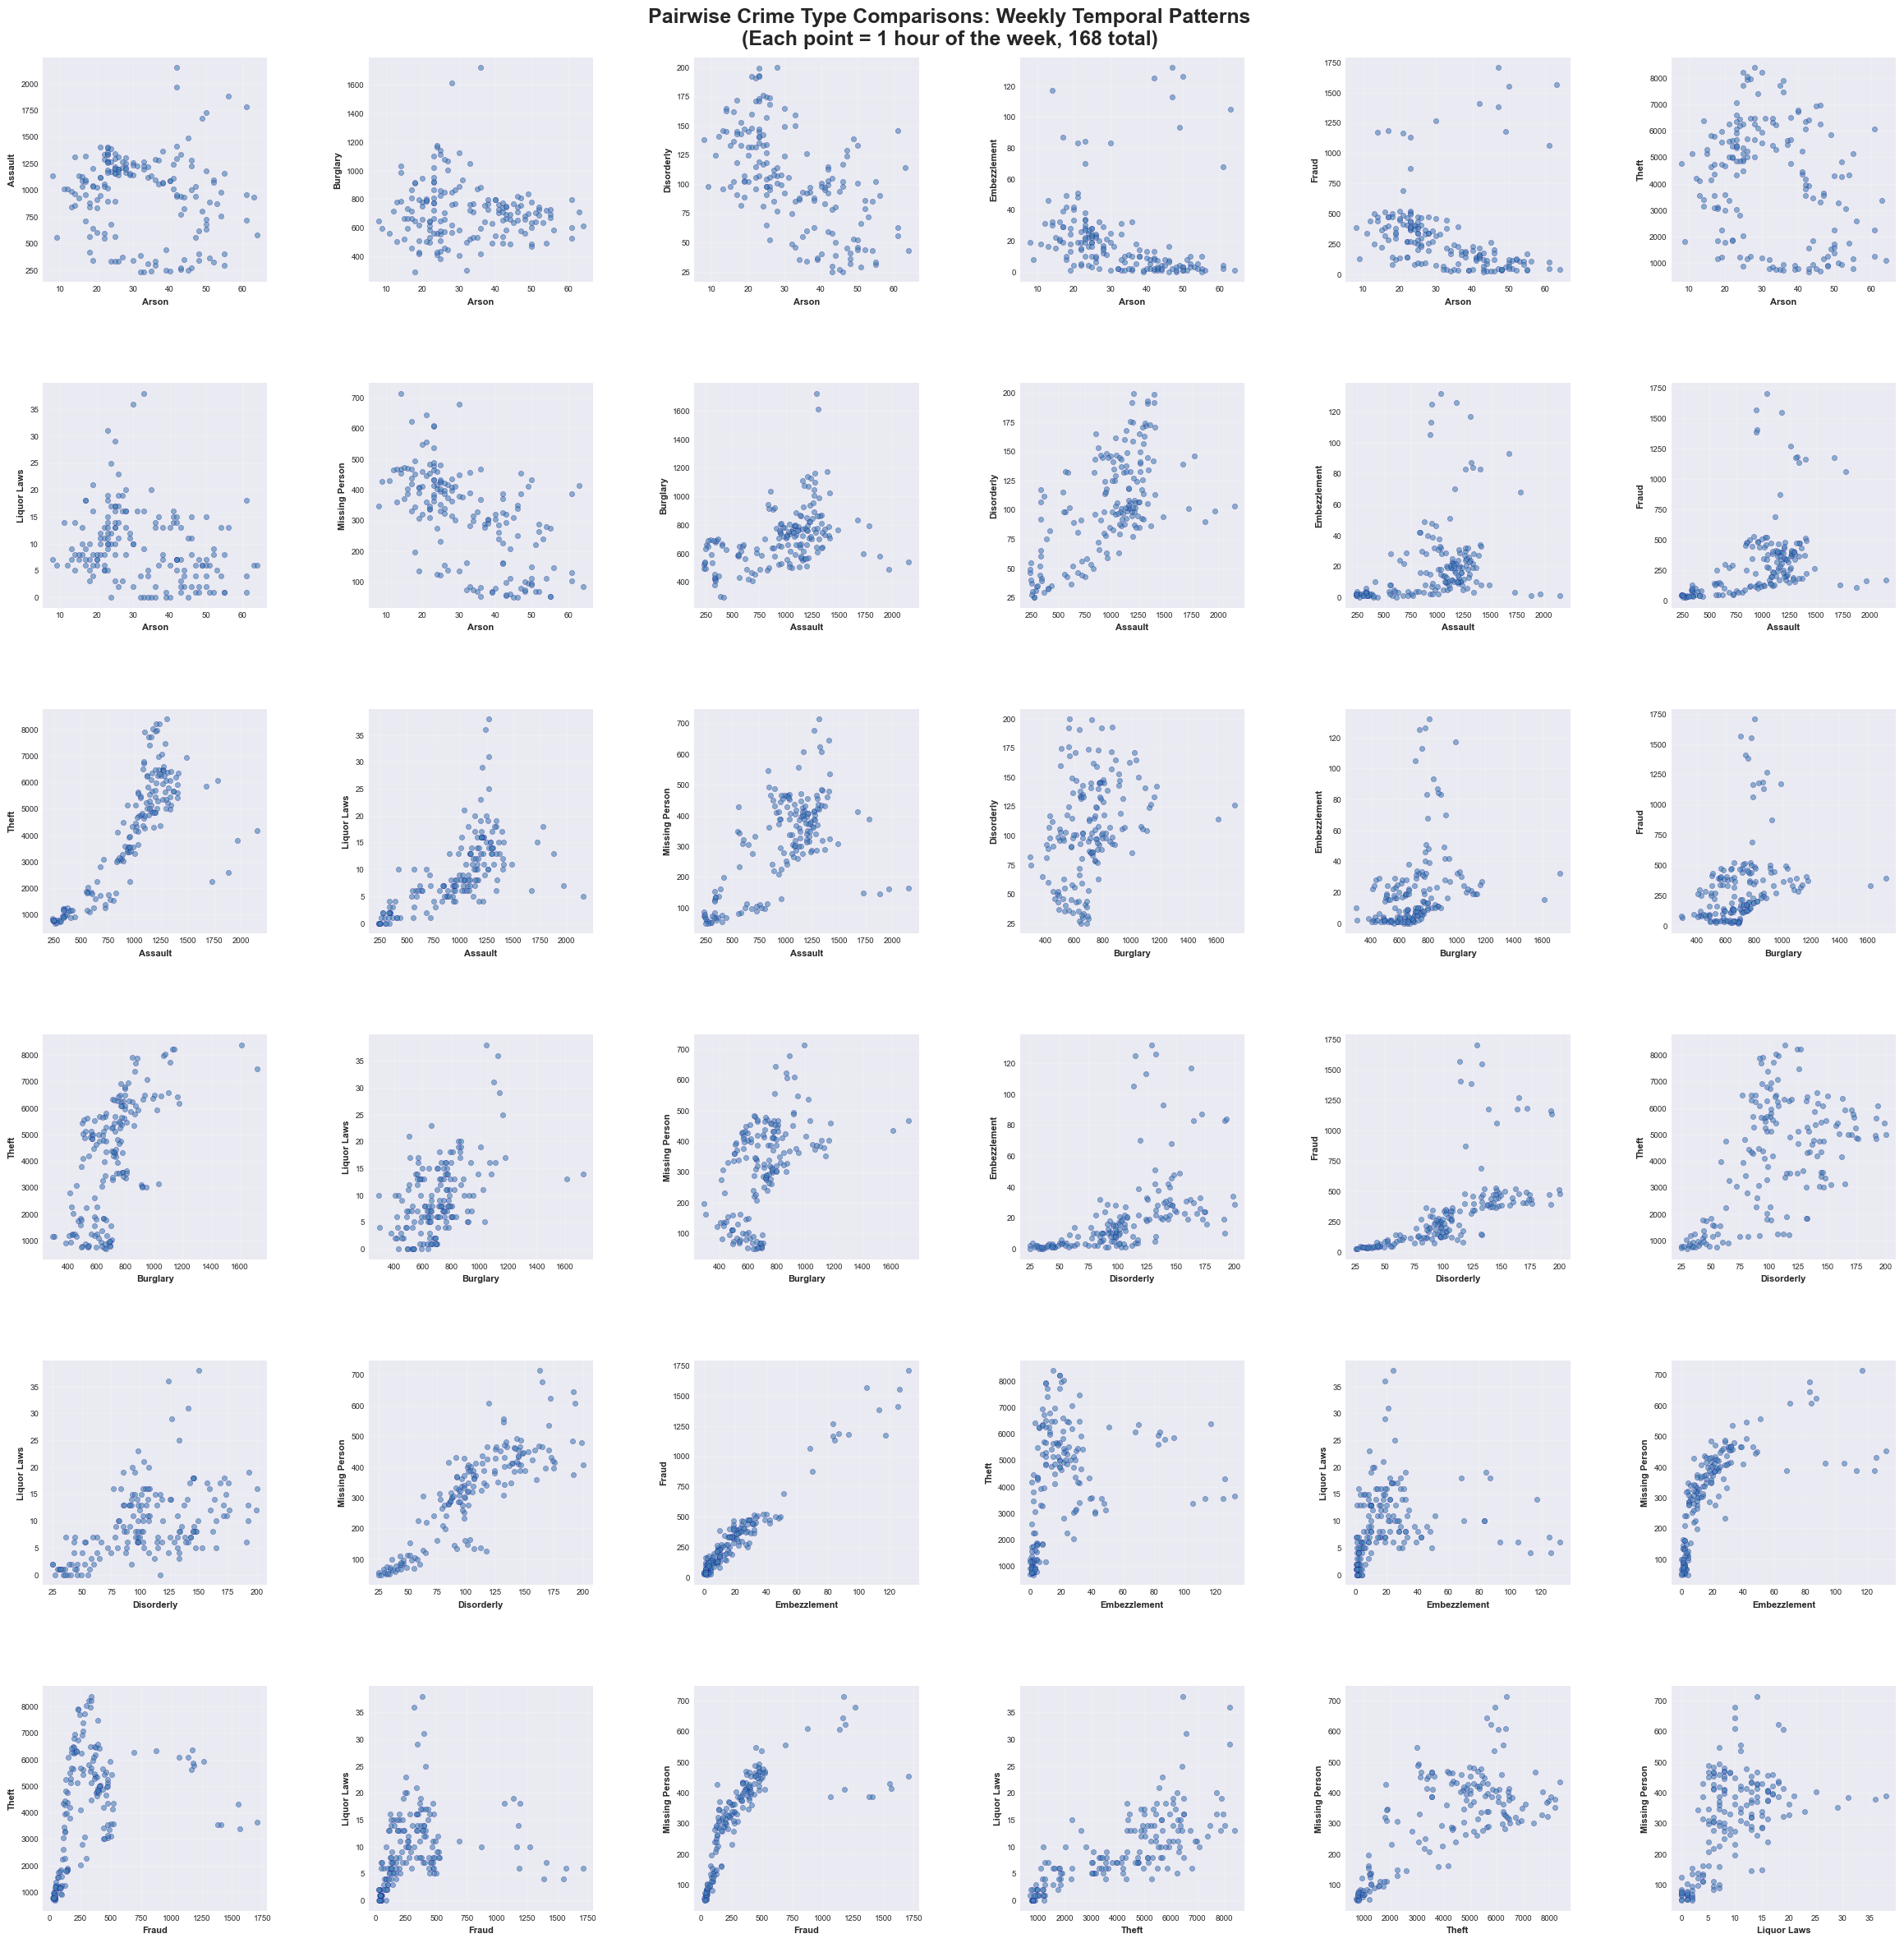

In [6]:
# Create 6x6 subplot matrix for 36 scatterplots
fig, axes = plt.subplots(6, 6, figsize=(24, 24))
fig.suptitle('Pairwise Crime Type Comparisons: Weekly Temporal Patterns\n(Each point = 1 hour of the week, 168 total)', 
             fontsize=18, fontweight='bold', y=0.995)

# Flatten axes for easier iteration
axes_flat = axes.flatten()

# Plot each pair
for idx, (crime1, crime2) in enumerate(crime_pairs):
    ax = axes_flat[idx]
    
    # Get hourly counts for both crimes
    x = hourly_counts[crime1]
    y = hourly_counts[crime2]
    
    # Create scatter plot
    ax.scatter(x, y, alpha=0.6, s=20, color='steelblue', edgecolors='darkblue', linewidths=0.3)
    
    # Shorten crime names for labels
    c1_short = crime1.replace('Larceny/Theft', 'Theft').replace('Disorderly Conduct', 'Disorderly')
    c2_short = crime2.replace('Larceny/Theft', 'Theft').replace('Disorderly Conduct', 'Disorderly')
    
    # Set labels with readable font
    ax.set_xlabel(c1_short, fontsize=8, fontweight='bold')
    ax.set_ylabel(c2_short, fontsize=8, fontweight='bold')
    
    # Smaller tick labels
    ax.tick_params(axis='both', which='major', labelsize=7)
    
    # Add light grid
    ax.grid(True, alpha=0.3, linewidth=0.5)

# Adjust layout to squeeze plots together
plt.subplots_adjust(left=0.04, right=0.98, top=0.97, bottom=0.03, hspace=0.45, wspace=0.45)

# Save the figure
plt.savefig('crime_pairwise_scatterplots.png', dpi=150, bbox_inches='tight')
print("\n✓ Created 6x6 matrix of 36 scatterplots")
print("✓ Saved as 'crime_pairwise_scatterplots.png'")

plt.show()

## Step 6: Visual Inspection Questions

Now look at the 6x6 matrix above and answer these questions:

### Question 1: Which crime-types look correlated?

**Instructions:** Look for scatterplots where points form a clear upward diagonal line (positive correlation).

**Your observations:**

Crime pairs that show strong positive correlation include:

1. **[Your observation]** - 
2. **[Your observation]** - 
3. **[Your observation]** - 

These correlations suggest that these crime types follow similar weekly rhythms.

### Question 2: Which crime-types look very different (uncorrelated)?

**Instructions:** Look for scatterplots where points are scattered randomly with no clear pattern.

**Your observations:**

Crime pairs that show little to no correlation include:

1. **[Your observation]** - 
2. **[Your observation]** - 
3. **[Your observation]** - 

These pairs suggest very different temporal patterns.

### Question 3: For a strongly correlated pair - Why might they follow the same weekly rhythm?

**Your analysis (your own thinking):**

**Selected pair:** [Crime 1] vs [Crime 2]

**Why they might correlate:**

1. 
2. 
3. 
4. 

**Example:** Assault vs Disorderly Conduct might correlate because:
- Both are related to nightlife and alcohol consumption
- Both peak on weekend nights when bars close
- Both involve public disturbances in high-traffic areas
- Both are influenced by the same social contexts (parties, crowds, intoxication)

### Question 4: For an uncorrelated pair - What does this tell you about different contexts?

**Your analysis (your own thinking):**

**Selected pair:** [Crime 1] vs [Crime 2]

**Why they don't correlate:**

1. 
2. 
3. 
4. 

**Example:** Embezzlement vs Liquor Laws might not correlate because:
- Embezzlement is white-collar crime occurring in business settings
- Liquor Laws violations are street-level enforcement
- Embezzlement has reporting delays (discovered weeks/months later)
- Liquor Laws violations are immediate (caught in the act)
- Different victim profiles and reporting mechanisms
- Different times of day (business hours vs nightlife hours)

## Bonus: Calculate Correlation Coefficients

Let's quantify the visual patterns with Pearson correlation coefficients

In [7]:
# Calculate correlation coefficients for all pairs
correlations = []

for crime1, crime2 in crime_pairs:
    x = hourly_counts[crime1]
    y = hourly_counts[crime2]
    corr = np.corrcoef(x, y)[0, 1]
    correlations.append((crime1, crime2, corr))

# Sort by correlation (highest to lowest)
correlations_sorted = sorted(correlations, key=lambda x: x[2], reverse=True)

print("\n" + "="*80)
print("CORRELATION COEFFICIENTS (Pearson r)")
print("="*80)
print("\nMOST CORRELATED PAIRS (Top 10):")
print("-" * 80)
for i, (c1, c2, corr) in enumerate(correlations_sorted[:10], 1):
    print(f"{i:2d}. {c1:25s} vs {c2:25s}  r = {corr:6.3f}")

print("\n" + "="*80)
print("LEAST CORRELATED PAIRS (Bottom 10):")
print("-" * 80)
for i, (c1, c2, corr) in enumerate(correlations_sorted[-10:], 1):
    print(f"{i:2d}. {c1:25s} vs {c2:25s}  r = {corr:6.3f}")

print("\n" + "="*80)
print("\nInterpretation:")
print("  r close to +1.0 = strong positive correlation (similar patterns)")
print("  r close to  0.0 = no correlation (different patterns)")
print("  r close to -1.0 = negative correlation (opposite patterns)")
print("="*80)


CORRELATION COEFFICIENTS (Pearson r)

MOST CORRELATED PAIRS (Top 10):
--------------------------------------------------------------------------------
 1. Embezzlement              vs Fraud                      r =  0.974
 2. Disorderly Conduct        vs Missing Person             r =  0.856
 3. Assault                   vs Larceny/Theft              r =  0.795
 4. Larceny/Theft             vs Liquor Laws                r =  0.743
 5. Fraud                     vs Missing Person             r =  0.698
 6. Larceny/Theft             vs Missing Person             r =  0.696
 7. Embezzlement              vs Missing Person             r =  0.654
 8. Assault                   vs Liquor Laws                r =  0.635
 9. Burglary                  vs Larceny/Theft              r =  0.631
10. Assault                   vs Missing Person             r =  0.623

LEAST CORRELATED PAIRS (Bottom 10):
--------------------------------------------------------------------------------
 1. Fraud           

## Summary

You've now:
1. ✓ Created 36 pairwise scatterplots comparing your 9 Personal Focus Crimes
2. ✓ Visually identified correlated and uncorrelated crime pairs
3. ✓ Analyzed why certain crimes follow similar temporal patterns
4. ✓ Analyzed why certain crimes have different temporal patterns
5. ✓ Calculated correlation coefficients to quantify the relationships

**Next:** Exercise 3.2 will add linear regression fits to these scatterplots!